<a href="https://colab.research.google.com/github/blancabarrera2987/ModelosAnaliticosUnicafam202607/blob/main/PARCIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PARCIAL MODELO K-MEANS**

Diplomado de Analítica de Datos

In [ ]:
# Paso 1. Importar todas las librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Paso 2. Importar el dataset
dataset=pd.read_excel("/content/crime_data.xlsx")

In [12]:
dataset.head()

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [10]:
# Paso 3. Seleccionar las columnas para determinar el cluster
X=dataset.iloc[:,[3,4]].values

In [11]:
X

array([[58. , 21.2],
       [48. , 44.5],
       [80. , 31. ],
       [50. , 19.5],
       [91. , 40.6],
       [78. , 38.7],
       [77. , 11.1],
       [72. , 15.8],
       [80. , 31.9],
       [60. , 25.8],
       [83. , 20.2],
       [54. , 14.2],
       [83. , 24. ],
       [65. , 21. ],
       [57. , 11.3],
       [66. , 18. ],
       [52. , 16.3],
       [66. , 22.2],
       [51. ,  7.8],
       [67. , 27.8],
       [85. , 16.3],
       [74. , 35.1],
       [66. , 14.9],
       [44. , 17.1],
       [70. , 28.2],
       [53. , 16.4],
       [62. , 16.5],
       [81. , 46. ],
       [56. ,  9.5],
       [89. , 18.8],
       [70. , 32.1],
       [86. , 26.1],
       [45. , 16.1],
       [44. ,  7.3],
       [75. , 21.4],
       [68. , 20. ],
       [67. , 29.3],
       [72. , 14.9],
       [87. ,  8.3],
       [48. , 22.5],
       [45. , 12.8],
       [59. , 26.9],
       [80. , 25.5],
       [80. , 22.9],
       [32. , 11.2],
       [63. , 20.7],
       [73. , 26.2],
       [39. ,

In [13]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init is explicitly set
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


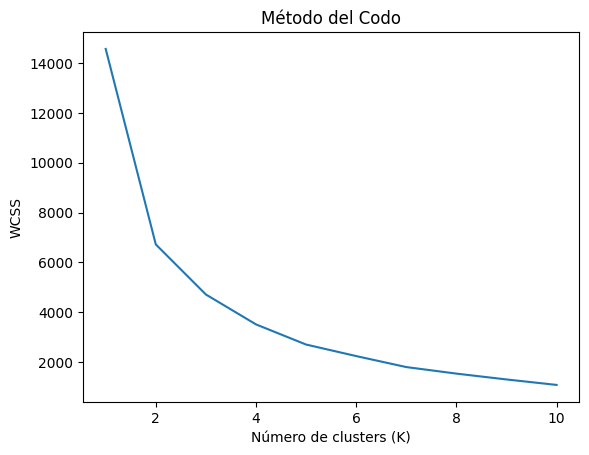

In [14]:
plt.plot(range(1, 11), wcss)
plt.title('Método del Codo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('WCSS')
plt.show()


### Aplicar K-Means con el número óptimo de clusters

In [15]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)


### Visualización de los Clusters

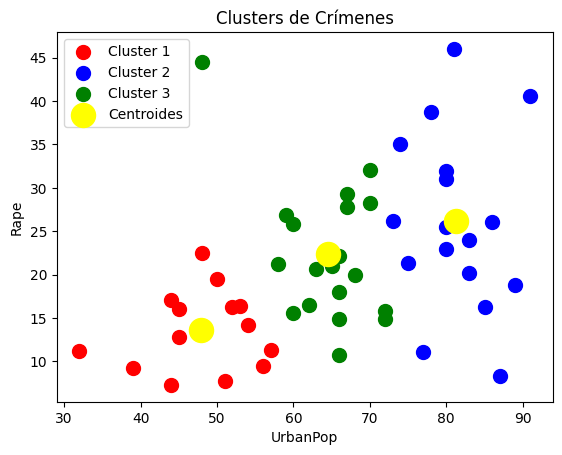

In [16]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroides')
plt.title('Clusters de Crímenes')
plt.xlabel('UrbanPop')
plt.ylabel('Rape')
plt.legend()
plt.show()


In [17]:
dataset['Cluster'] = y_kmeans
display(dataset.head())


,Unnamed: 0,Murder,Assault,UrbanPop,Rape,Cluster
0,Alabama,13.2,236,58,21.2,2
1,Alaska,10.0,263,48,44.5,2
2,Arizona,8.1,294,80,31.0,1
3,Arkansas,8.8,190,50,19.5,0
4,California,9.0,276,91,40.6,1


In [18]:
cluster_summary = dataset.groupby('Cluster')[['UrbanPop', 'Rape']].mean()
display(cluster_summary)


,UrbanPop,Rape
Cluster,,
0,47.857143,13.664286
1,81.294118,26.123529
2,64.473684,22.431579


### 5. Recomendaciones Finales

Para terminar nuestro análisis de los grupos de criminalidad, aquí van unas recomendaciones clave:

1.  **No todo es igual:** Cada grupo de estados necesita soluciones diferentes. ¡Hay que ser específicos con las estrategias!
2.  **Más datos, mejor análisis:** Si añadimos más información (como cuánto ganan las personas o qué tan educadas son), entenderemos mejor por qué los estados son como son.
3.  **Hay que estar al día:** La criminalidad cambia, así que hay que revisar el modelo y los datos seguido para que nuestras soluciones sigan sirviendo.
4.  **Asegurarnos que los grupos son buenos:** Investigar un poco más para confirmar que los 3 grupos que encontramos son realmente los mejores y los más claros.
5.  **Aprender de otros:** Los estados del mismo grupo o de diferentes pueden compartir ideas para luchar contra el crimen. ¡Trabajar juntos es clave!